In [2]:
# Instala o pacote VGAM se ele ainda não estiver instalado
library(tidyverse)    # Data wrangling and visualization
library(VGAM)
library(survey)       # Survey analysis
library(readr)        # CSV reading
library(svyVGAM)
library(dplyr)
library(broom)
library(scales)
library(tidyr)
library(rlang)
library(purrr)
library(kableExtra)
library(emmeans)
library(readr)
library(srvyr)

library(car)
library(corrplot)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Carregando pacotes exigidos: stats4

Carregando pacotes exigidos: splines

Carregando pacotes exigidos: grid

Carregando pacotes exigidos: Matrix


Anexando pacote: 'Matrix'


Os seguintes objetos são mascarados por 'package:tidyr':

    expand, pack, unpack


Carregando pacotes exigidos: survival


Anexando pacote: 'survey'


O seguinte objeto é mascarado por 'package:VGAM':

    calibrate


O seguinte objeto é mascarado por 'package:graphics':

    dotchart



Anexando 

In [3]:
# Carregando os dados

df_grupo <- read_csv("data/grupo_maes_criancas_2019.csv")

Rows: 7815 Columns: 74
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): sexo, chave_domicio, chave_pessoa_filho, UF, chave_pessoa_mae, reg...
dbl (57): estrato_filho, UPA_PNS_filho, idade_filho, cor_raca_filho, curso_m...
lgl  (6): exercicio_3m, freq_exercicio_semana, peso_selecionado_sem_cal, pes...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Funçoes

In [4]:
#–– 1. Helper: build a survey.design object from any df + weight var ––

get_design <- function(df, weight_var) {
  df2 <- df %>%
    filter(!is.na(.data[[weight_var]]), !is.na(UPA_PNS), !is.na(estrato)) %>%
    mutate(
      UPA_PNS   = as.numeric(UPA_PNS),
      estrato   = as.numeric(estrato),
      !!weight_var := as.numeric(.data[[weight_var]])
    )
  options(survey.lonely.psu = "adjust")
  svydesign(
    ids     = ~UPA_PNS,
    strata  = ~estrato,
    weights = as.formula(paste0("~", weight_var)),
    data    = df2,
    nest    = TRUE
  )
}

In [28]:
# Tranformar a variável de sexo em numérica
df_grupo <- df_grupo %>%
  mutate(sexo_num = case_when(
    sexo == "Mulher" ~ 0,
    sexo == "Homem"  ~ 1,
    TRUE             ~ NA_real_
  ))

# Escolaridade para ordinal
df_grupo <- df_grupo %>%
  mutate(
    escolaridade_num = case_when(
      escolaridade == "Fundamental"     ~ 1,
      escolaridade == "Médio"           ~ 2,
      escolaridade == "Superior"        ~ 3,
      escolaridade == "Pós-graduação"   ~ 4,
      TRUE                              ~ NA_real_
    )
  )

df_grupo <- df_grupo %>%
  mutate(
    faixa_renda_num = case_when(
      faixa_renda == "<1 SM"        ~ 1,
      faixa_renda == "1 a <2 SM"    ~ 2,
      faixa_renda == "2 a <3 SM"    ~ 3,
      faixa_renda == "3 a <5 SM"    ~ 4,
      faixa_renda == "≥5 SM"        ~ 5,
      TRUE                          ~ NA_real_
    )
  )

df_grupo <- df_grupo %>%
  mutate(
    class_peso_ao_nascer_num = case_when(
      class_peso_ao_nascer == "ELBW"        ~ 1,
      class_peso_ao_nascer == "VLBW"        ~ 2,
      class_peso_ao_nascer == "LBW"         ~ 3,
      class_peso_ao_nascer == "NBW"         ~ 4,
      class_peso_ao_nascer == "Macrossomia" ~ 5,
      TRUE                                  ~ NA_real_
    )
  )

df_grupo <- df_grupo %>%
  mutate(
    class_ig_mae_num = case_when(
      class_ig_mae == "Extreme preterm"   ~ 1,
      class_ig_mae == "Very preterm"      ~ 2,
      class_ig_mae == "Moderate preterm"  ~ 3,
      class_ig_mae == "Late preterm"      ~ 4,
      class_ig_mae == "Term"              ~ 5,
      class_ig_mae == "Post-term"         ~ 6,
      TRUE                                ~ NA_real_
    )
  )
  
  df_grupo <- df_grupo %>%
  mutate(deficiencia = ifelse(is.na(deficiencia), 0, deficiencia))

In [73]:
unique(df_grupo$escolaridade_num)

[1]  3  2  1 NA  4

# Graficos

In [92]:
plot_survey_corr <- function(df_grupo, nome_grafico) {
  library(survey)
  library(corrplot)
  library(dplyr)

  # Mostrar quantas linhas o dataframe tem
  n_linhas <- nrow(df_grupo)
  message("Número de linhas no dataframe: ", n_linhas)

  # Define o objeto de desenho amostral
  svy_df <- df_grupo %>%
    as_survey_design(
      ids     = UPA_PNS_filho,
      strata  = estrato_filho,
      weights = peso_domicilio,
      nest    = TRUE
    )

  # Tratar PSU solitários
  options(survey.lonely.psu = "adjust")

  # Variáveis numéricas de interesse
  a <- c(
    'estado_vacinal','idade_mae',
    'imc','comorbidade','comorbidade_score',
    'sedentarismo','parto_prematuro','cesariana','baixo_peso_nascer',
    'PN_adequado','complicacoes_perinatais','risco_insulto_perinatal',
    'escolaridade_num','faixa_renda_num',
    'class_peso_ao_nascer_num','class_ig_mae_num'
  )

  # Cria a fórmula
  form <- as.formula(paste("~", paste(a, collapse = " + ")))

  # Matriz de covariância ponderada e correlação
  cov_mat <- svyvar(form, svy_df, na.rm = TRUE)
  cor_mat <- cov2cor(as.matrix(cov_mat))

  # Exibir no notebook (Jupyter ou RMarkdown)
  options(repr.plot.width = 20, repr.plot.height = 20)
  par(bg = "white", mar = c(4, 4, 6, 2))  # espaço extra no topo p/ título

  corrplot(
    cor_mat,
    method = "color",
    type = "upper",
    addCoef.col = "black",
    tl.col = "black",
    tl.cex = 1.2,
    number.cex = 0.8,
    col = colorRampPalette(c("red", "white", "blue"))(200),
    diag = FALSE
  )

  # Adiciona título com nome do gráfico
  title(main = nome_grafico, cex.main = 2)

  par(mfrow = c(1,1))

  # Salvar imagem como PNG
  png_filename <- paste0(nome_grafico, ".png")
  png(png_filename, width = 1600, height = 1600, res = 100)

  par(bg = "white", mar = c(4, 4, 6, 2))  # também no arquivo

  corrplot(
    cor_mat,
    method = "color",
    type = "upper",
    addCoef.col = "black",
    tl.col = "black",
    tl.cex = 1.2,
    number.cex = 0.8,
    col = colorRampPalette(c("red", "white", "blue"))(200),
    diag = FALSE
  )

  title(main = nome_grafico, cex.main = 2)

  dev.off()

  message("Gráfico salvo como: ", png_filename)
}



Número de linhas no dataframe: 7815

Gráfico salvo como: Matriz de Correlação - Geral.png



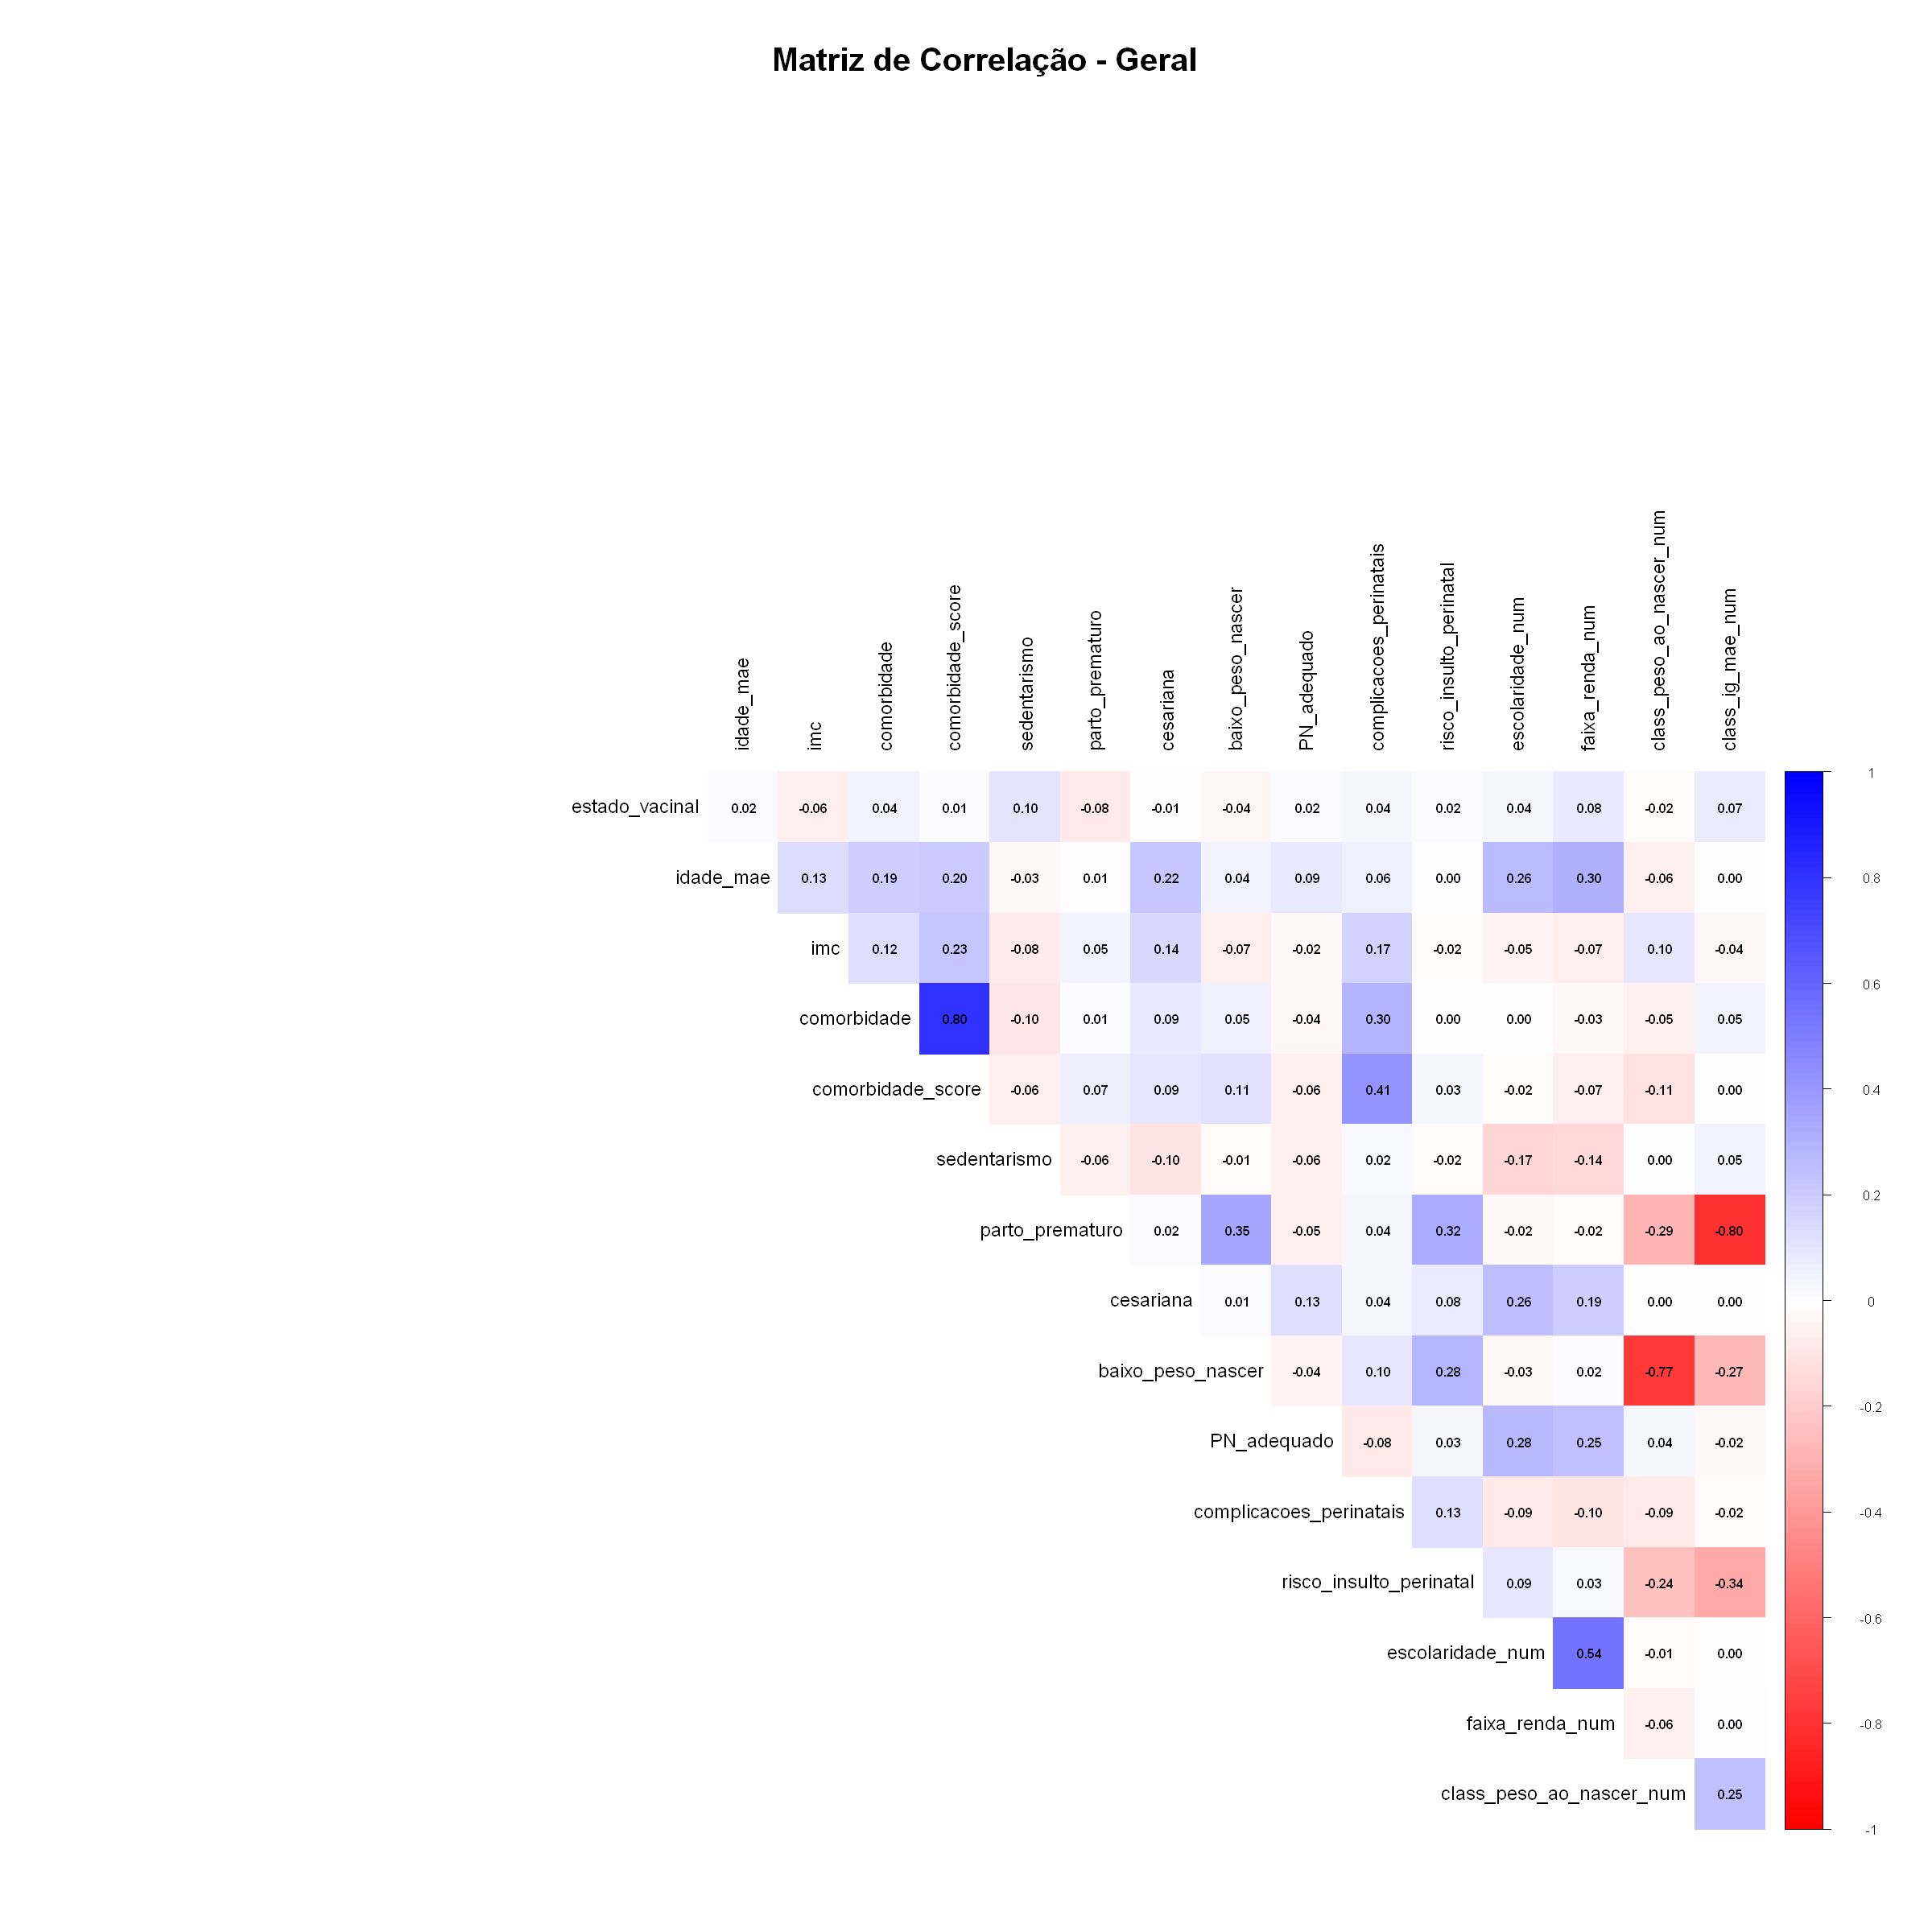

In [101]:
plot_survey_corr(df_grupo, "Matriz de Correlação - Geral")

### Filtrar meninos

Número de linhas no dataframe: 3946



Gráfico salvo como: Matriz de Correlação Meninos.png



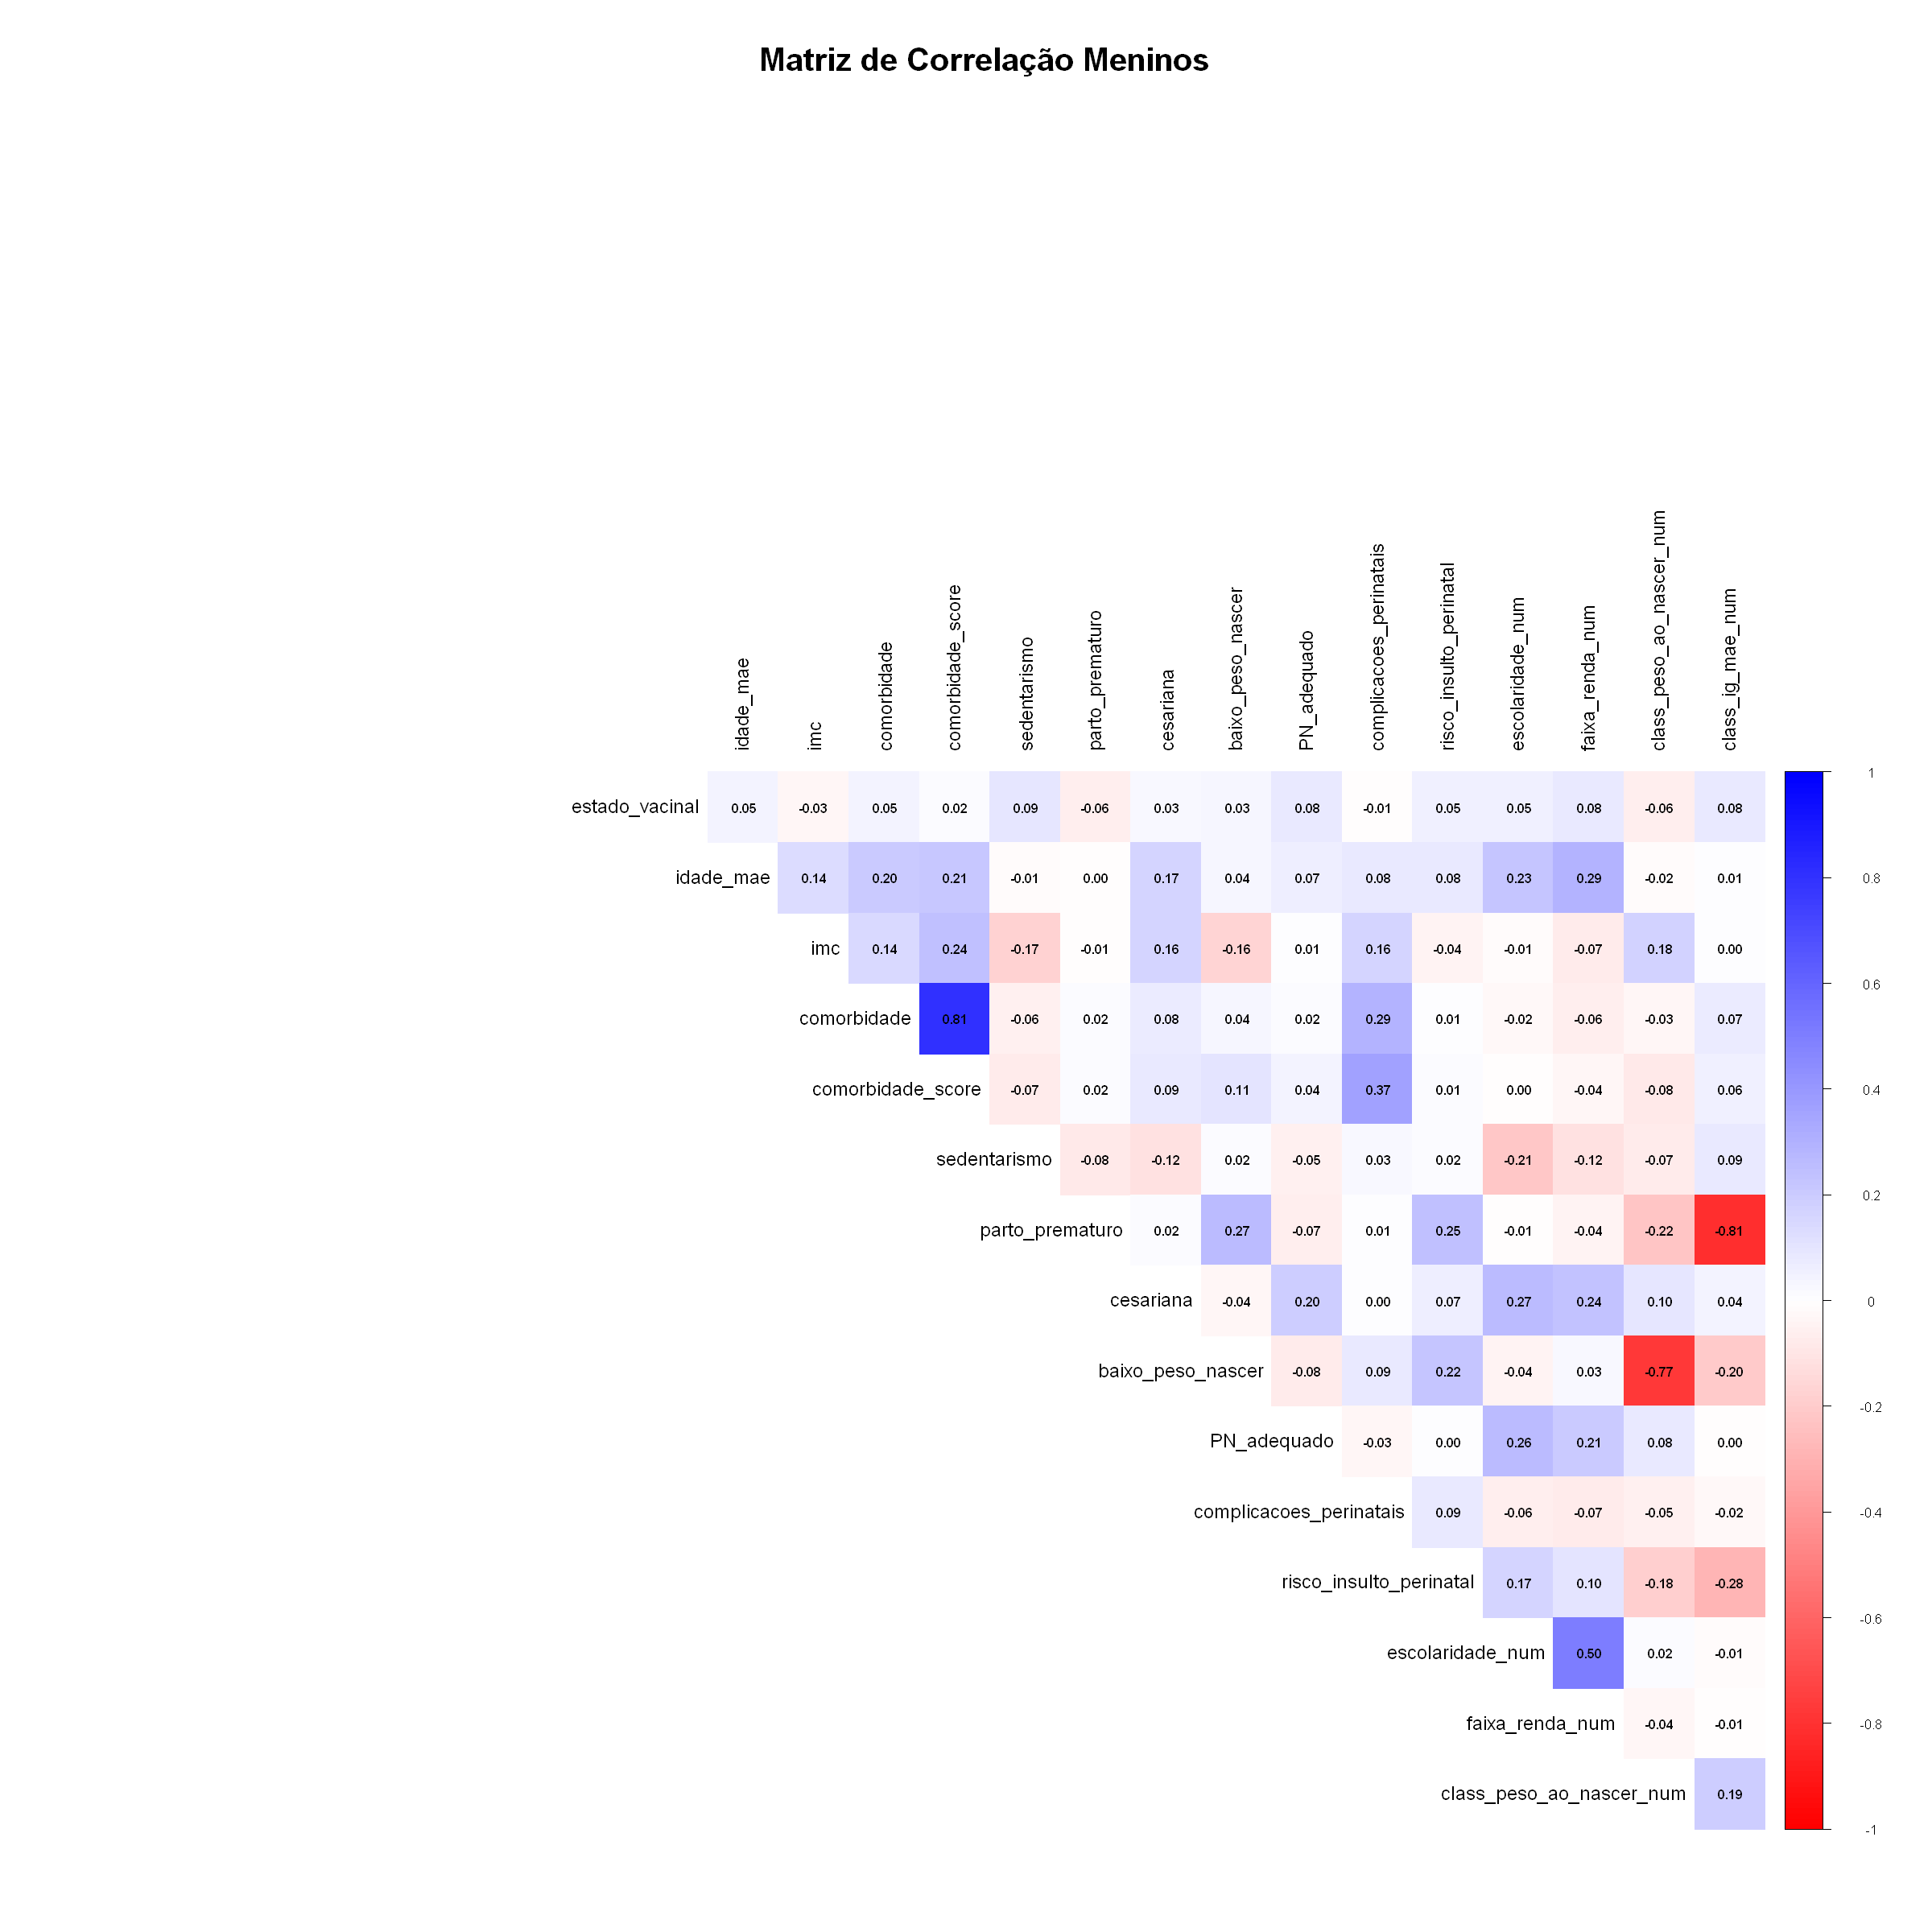

In [102]:
df_grupo_meninos <- df_grupo %>% filter(sexo_num == 1)
plot_survey_corr(df_grupo_meninos, "Matriz de Correlação Meninos")

### Filtrar Meninas

Número de linhas no dataframe: 3869

Gráfico salvo como: Matriz de Correlação Meninas.png



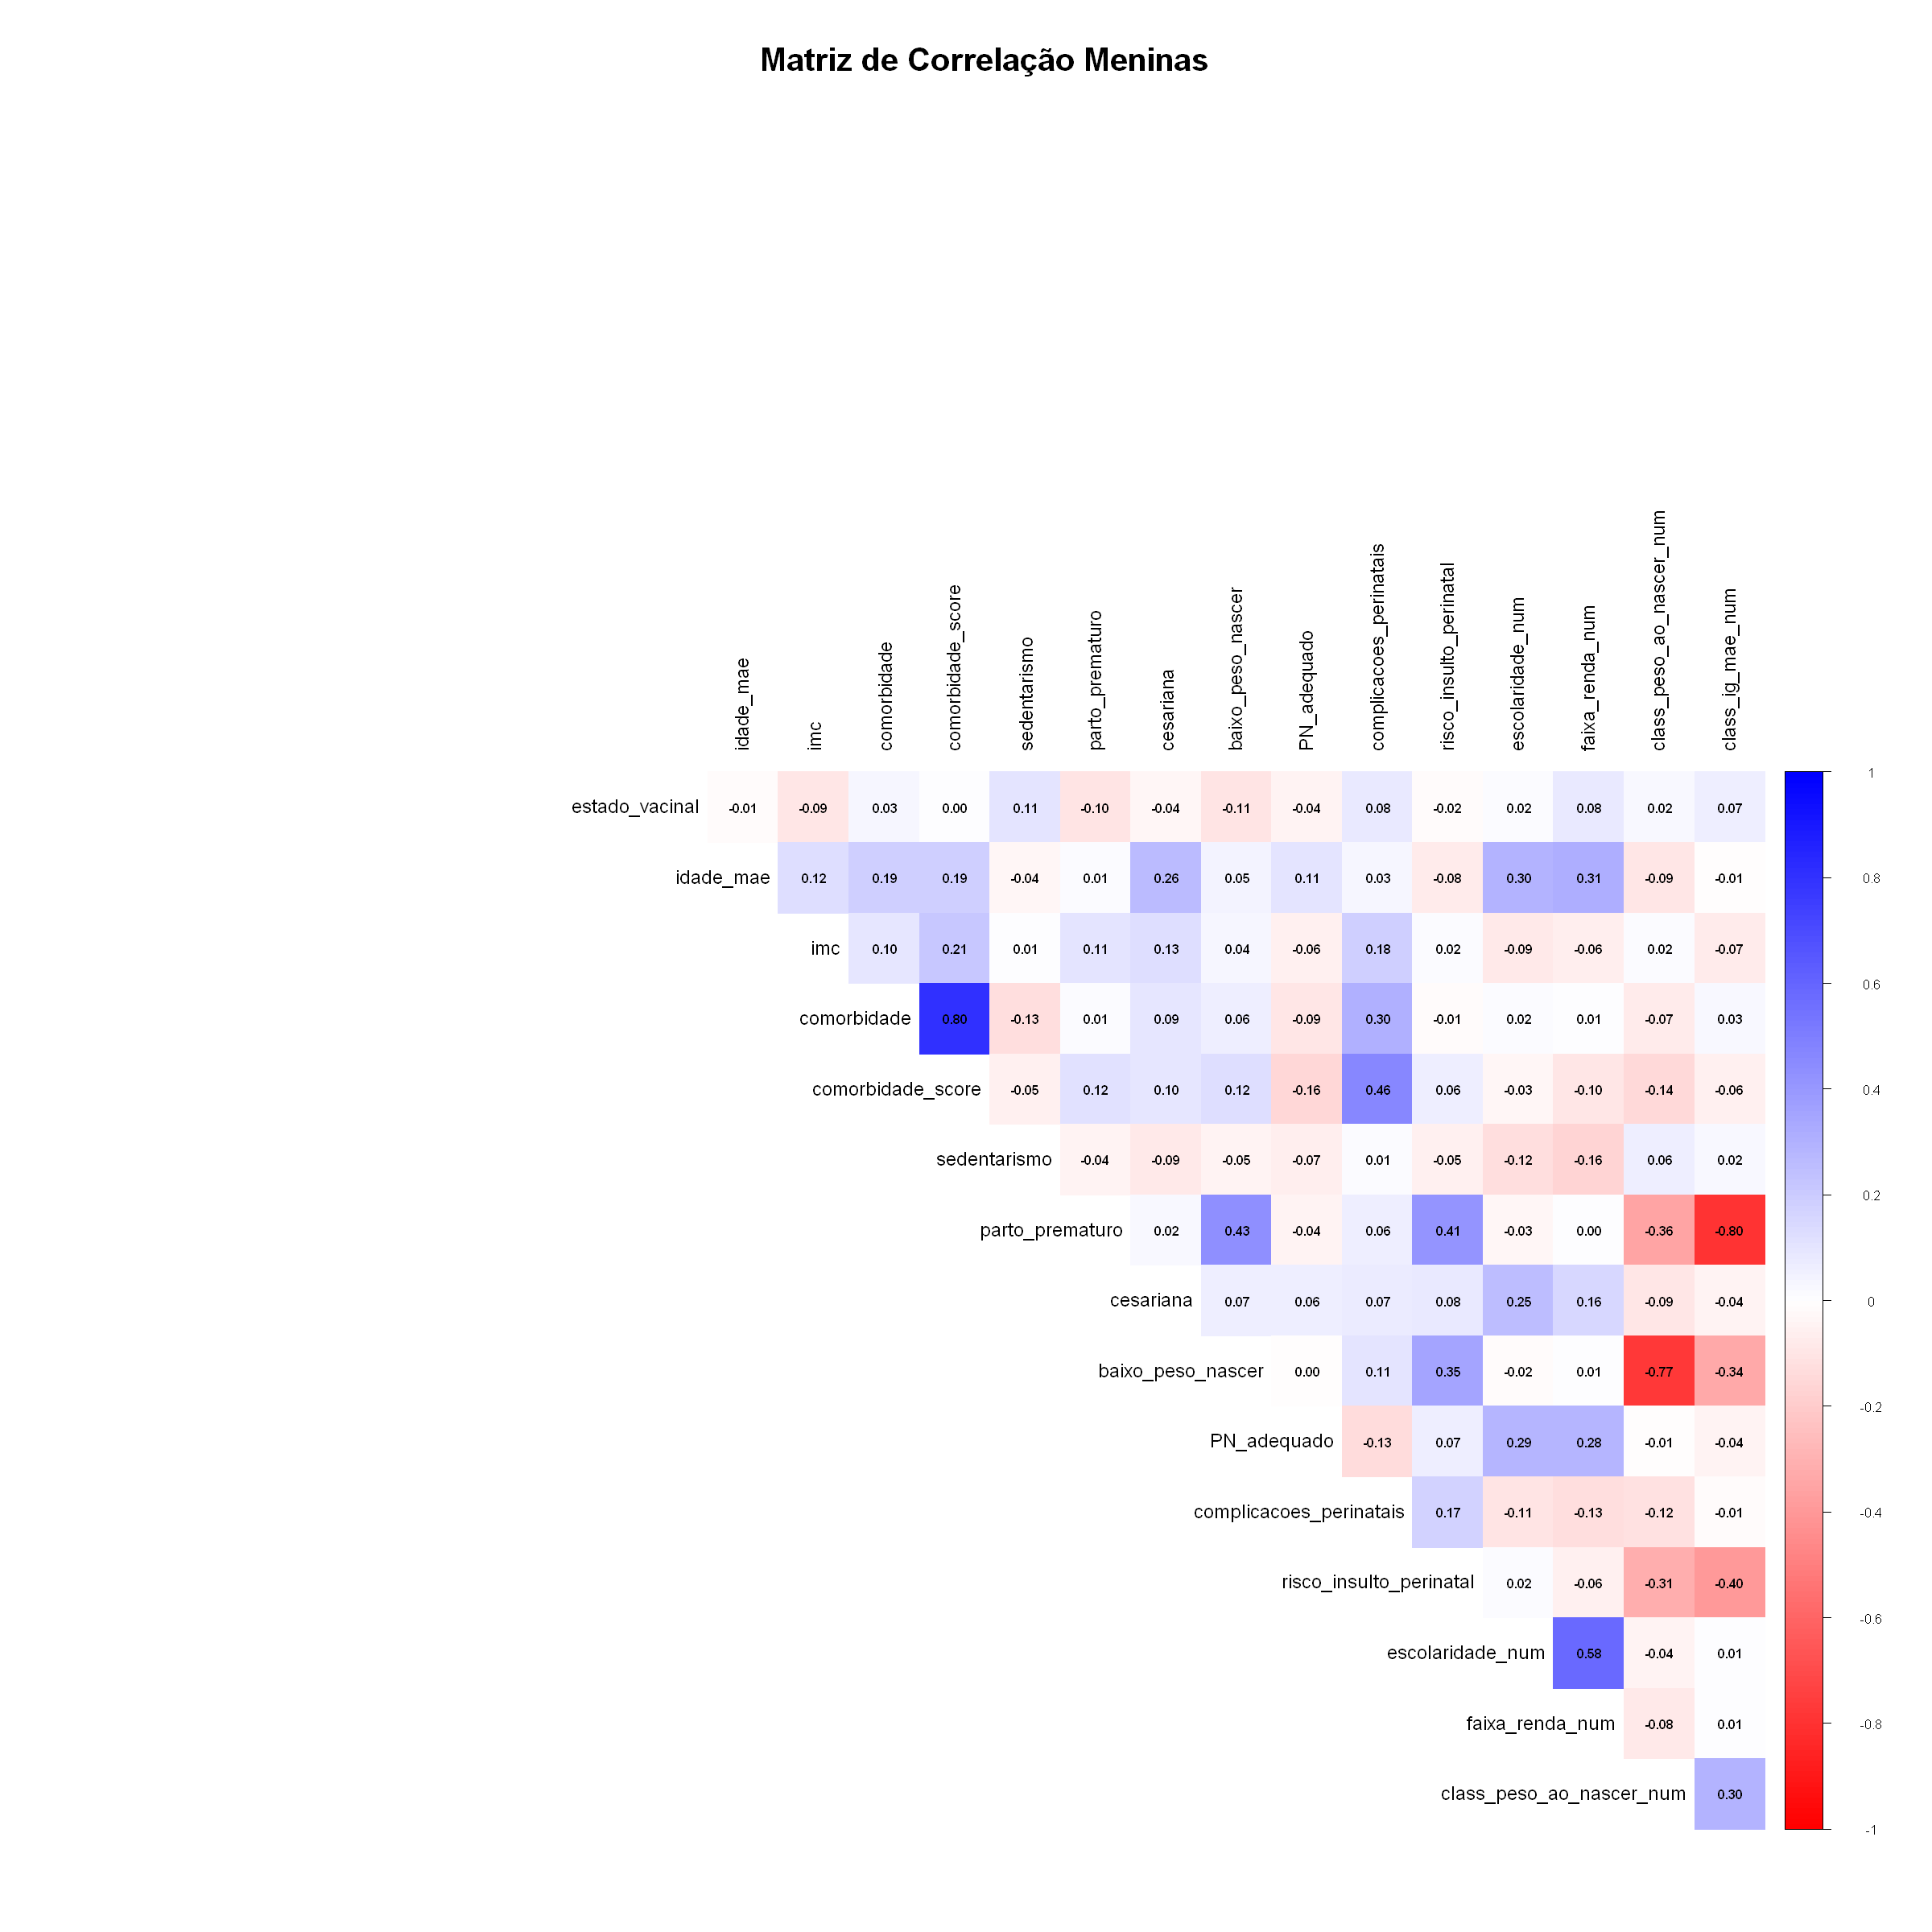

In [103]:
df_grupo_meninas <- df_grupo %>% filter(sexo_num == 0)
plot_survey_corr(df_grupo_meninas, "Matriz de Correlação Meninas")

### AMA = 1 meninos

Número de linhas no dataframe: 754



Gráfico salvo como: Matriz de Correlação Meninos AMA.png



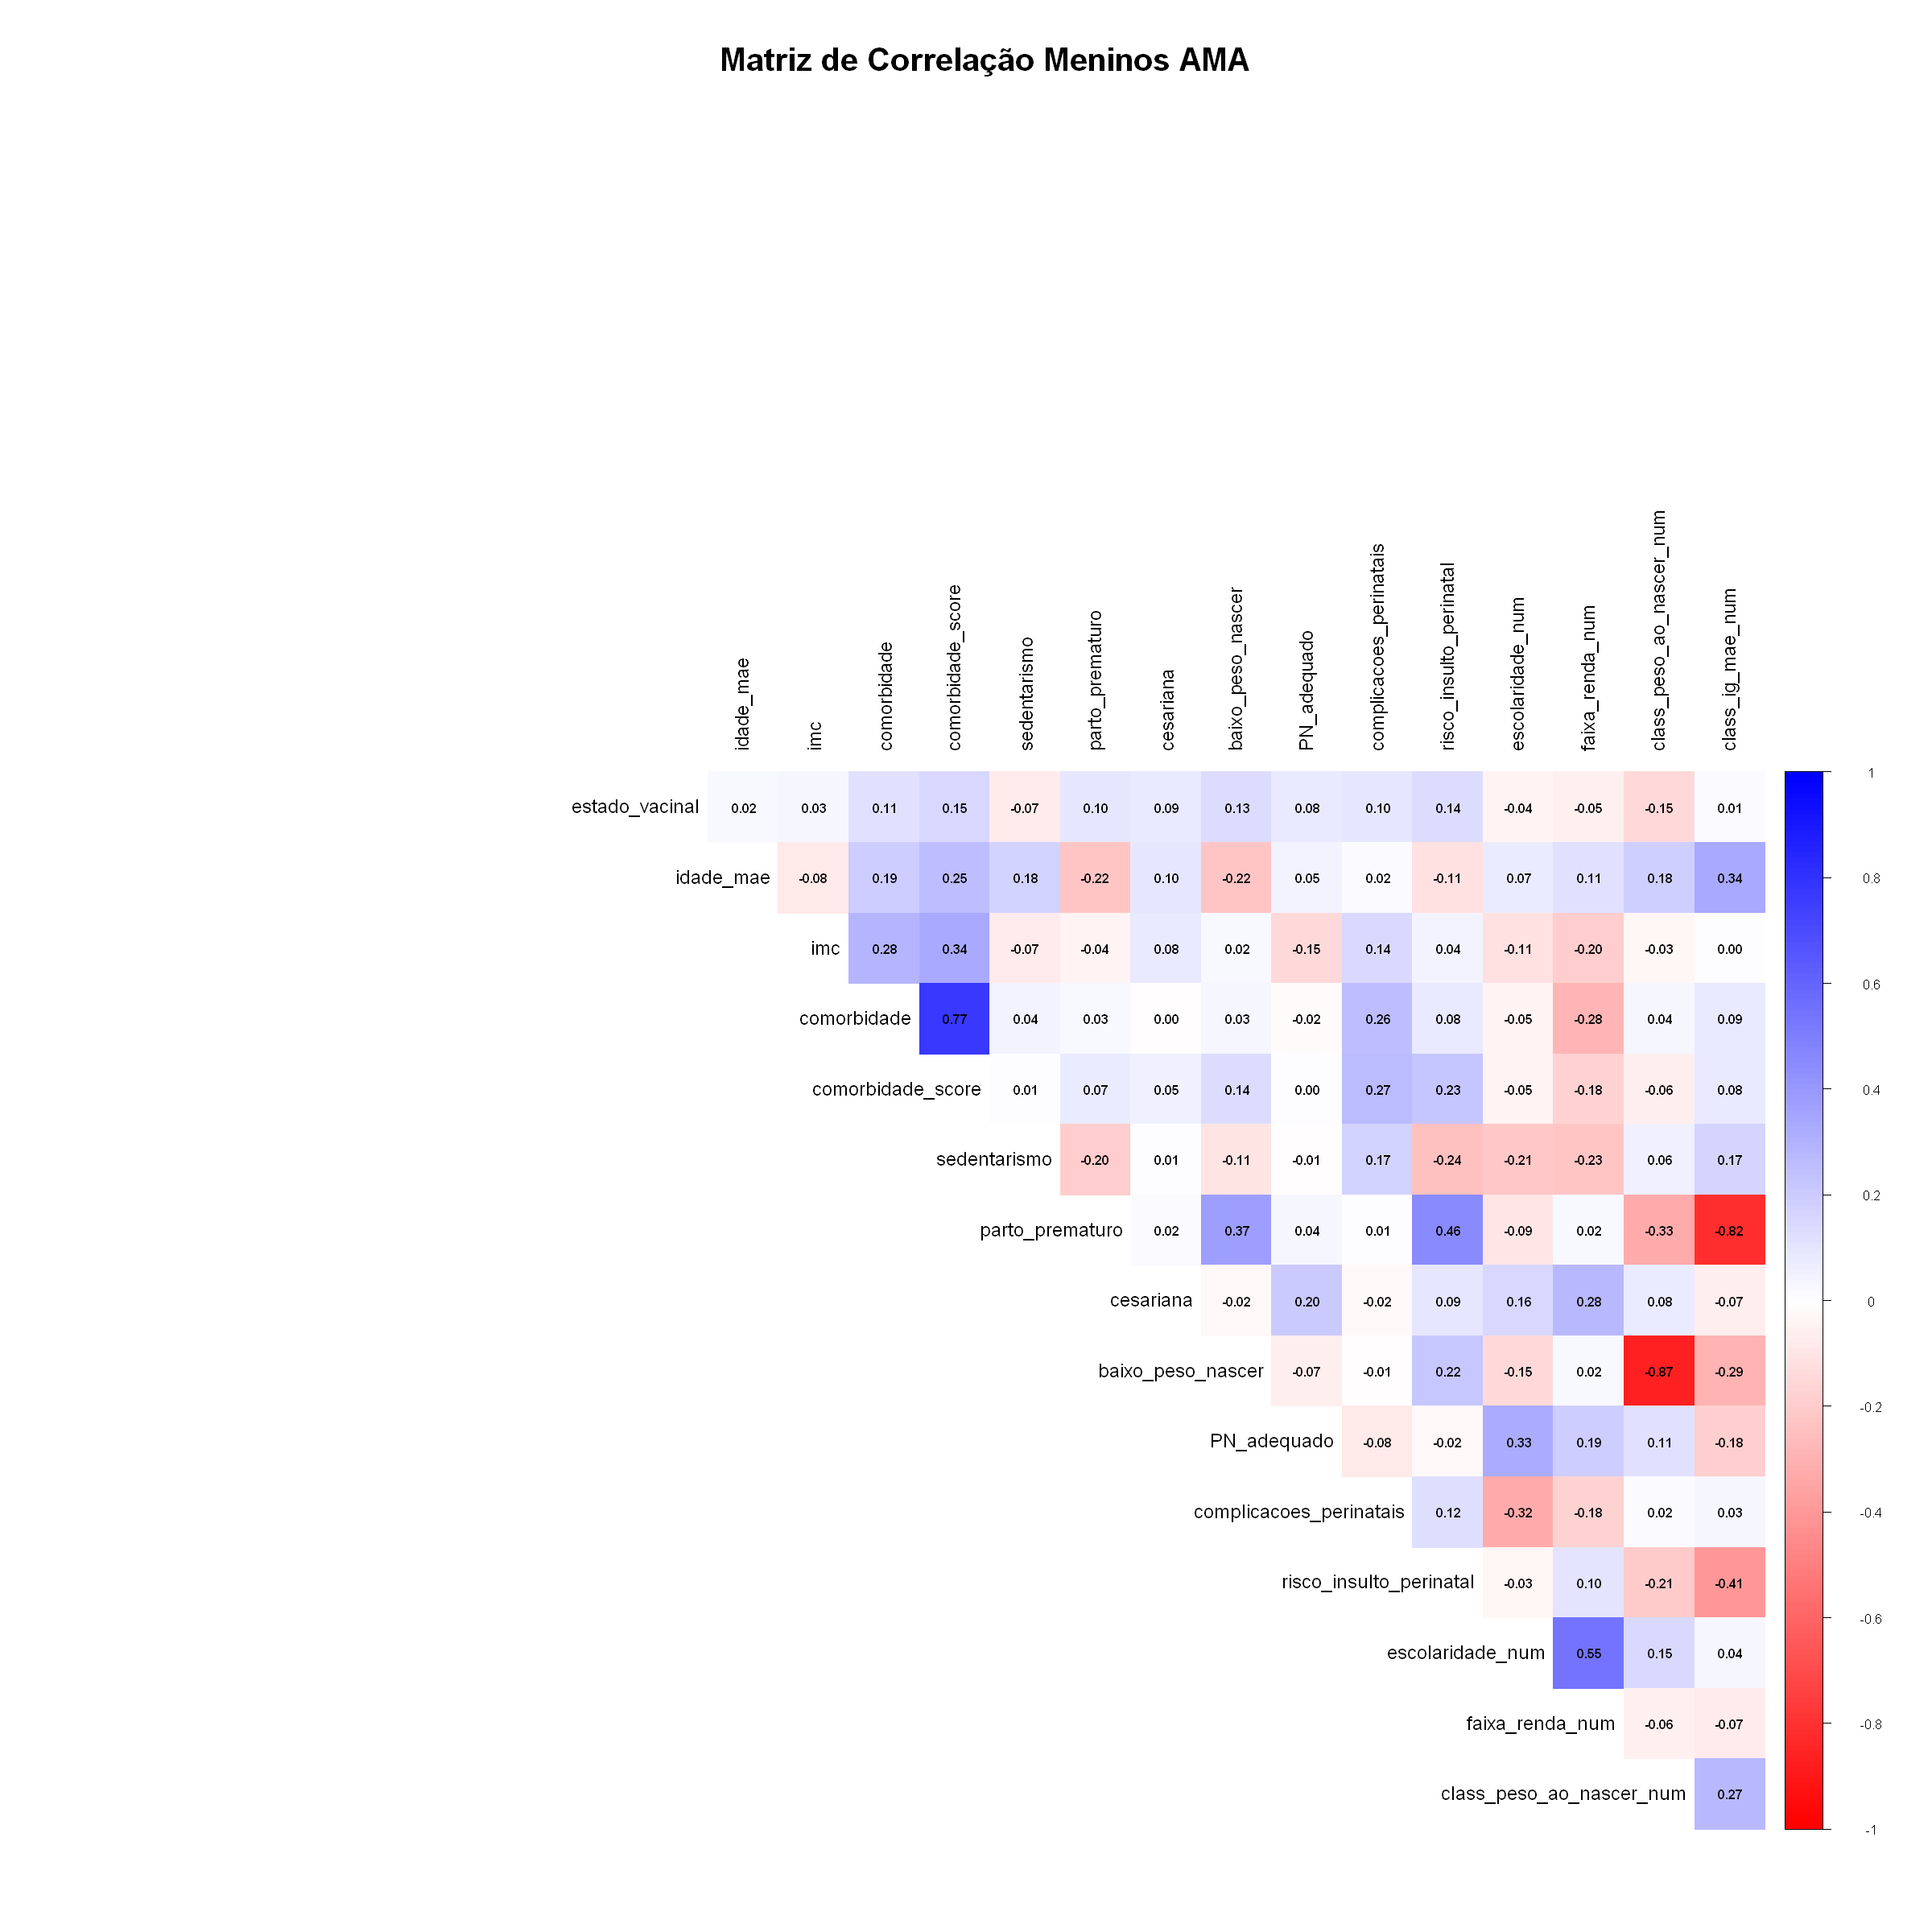

In [104]:
df_grupo_meninos_ama <- df_grupo %>% filter(sexo_num == 1, AMA == 1)
plot_survey_corr(df_grupo_meninos_ama, "Matriz de Correlação Meninos AMA")

### AMA = 1 meninas

Número de linhas no dataframe: 771

Gráfico salvo como: Matriz de Correlação Meninas AMA.png



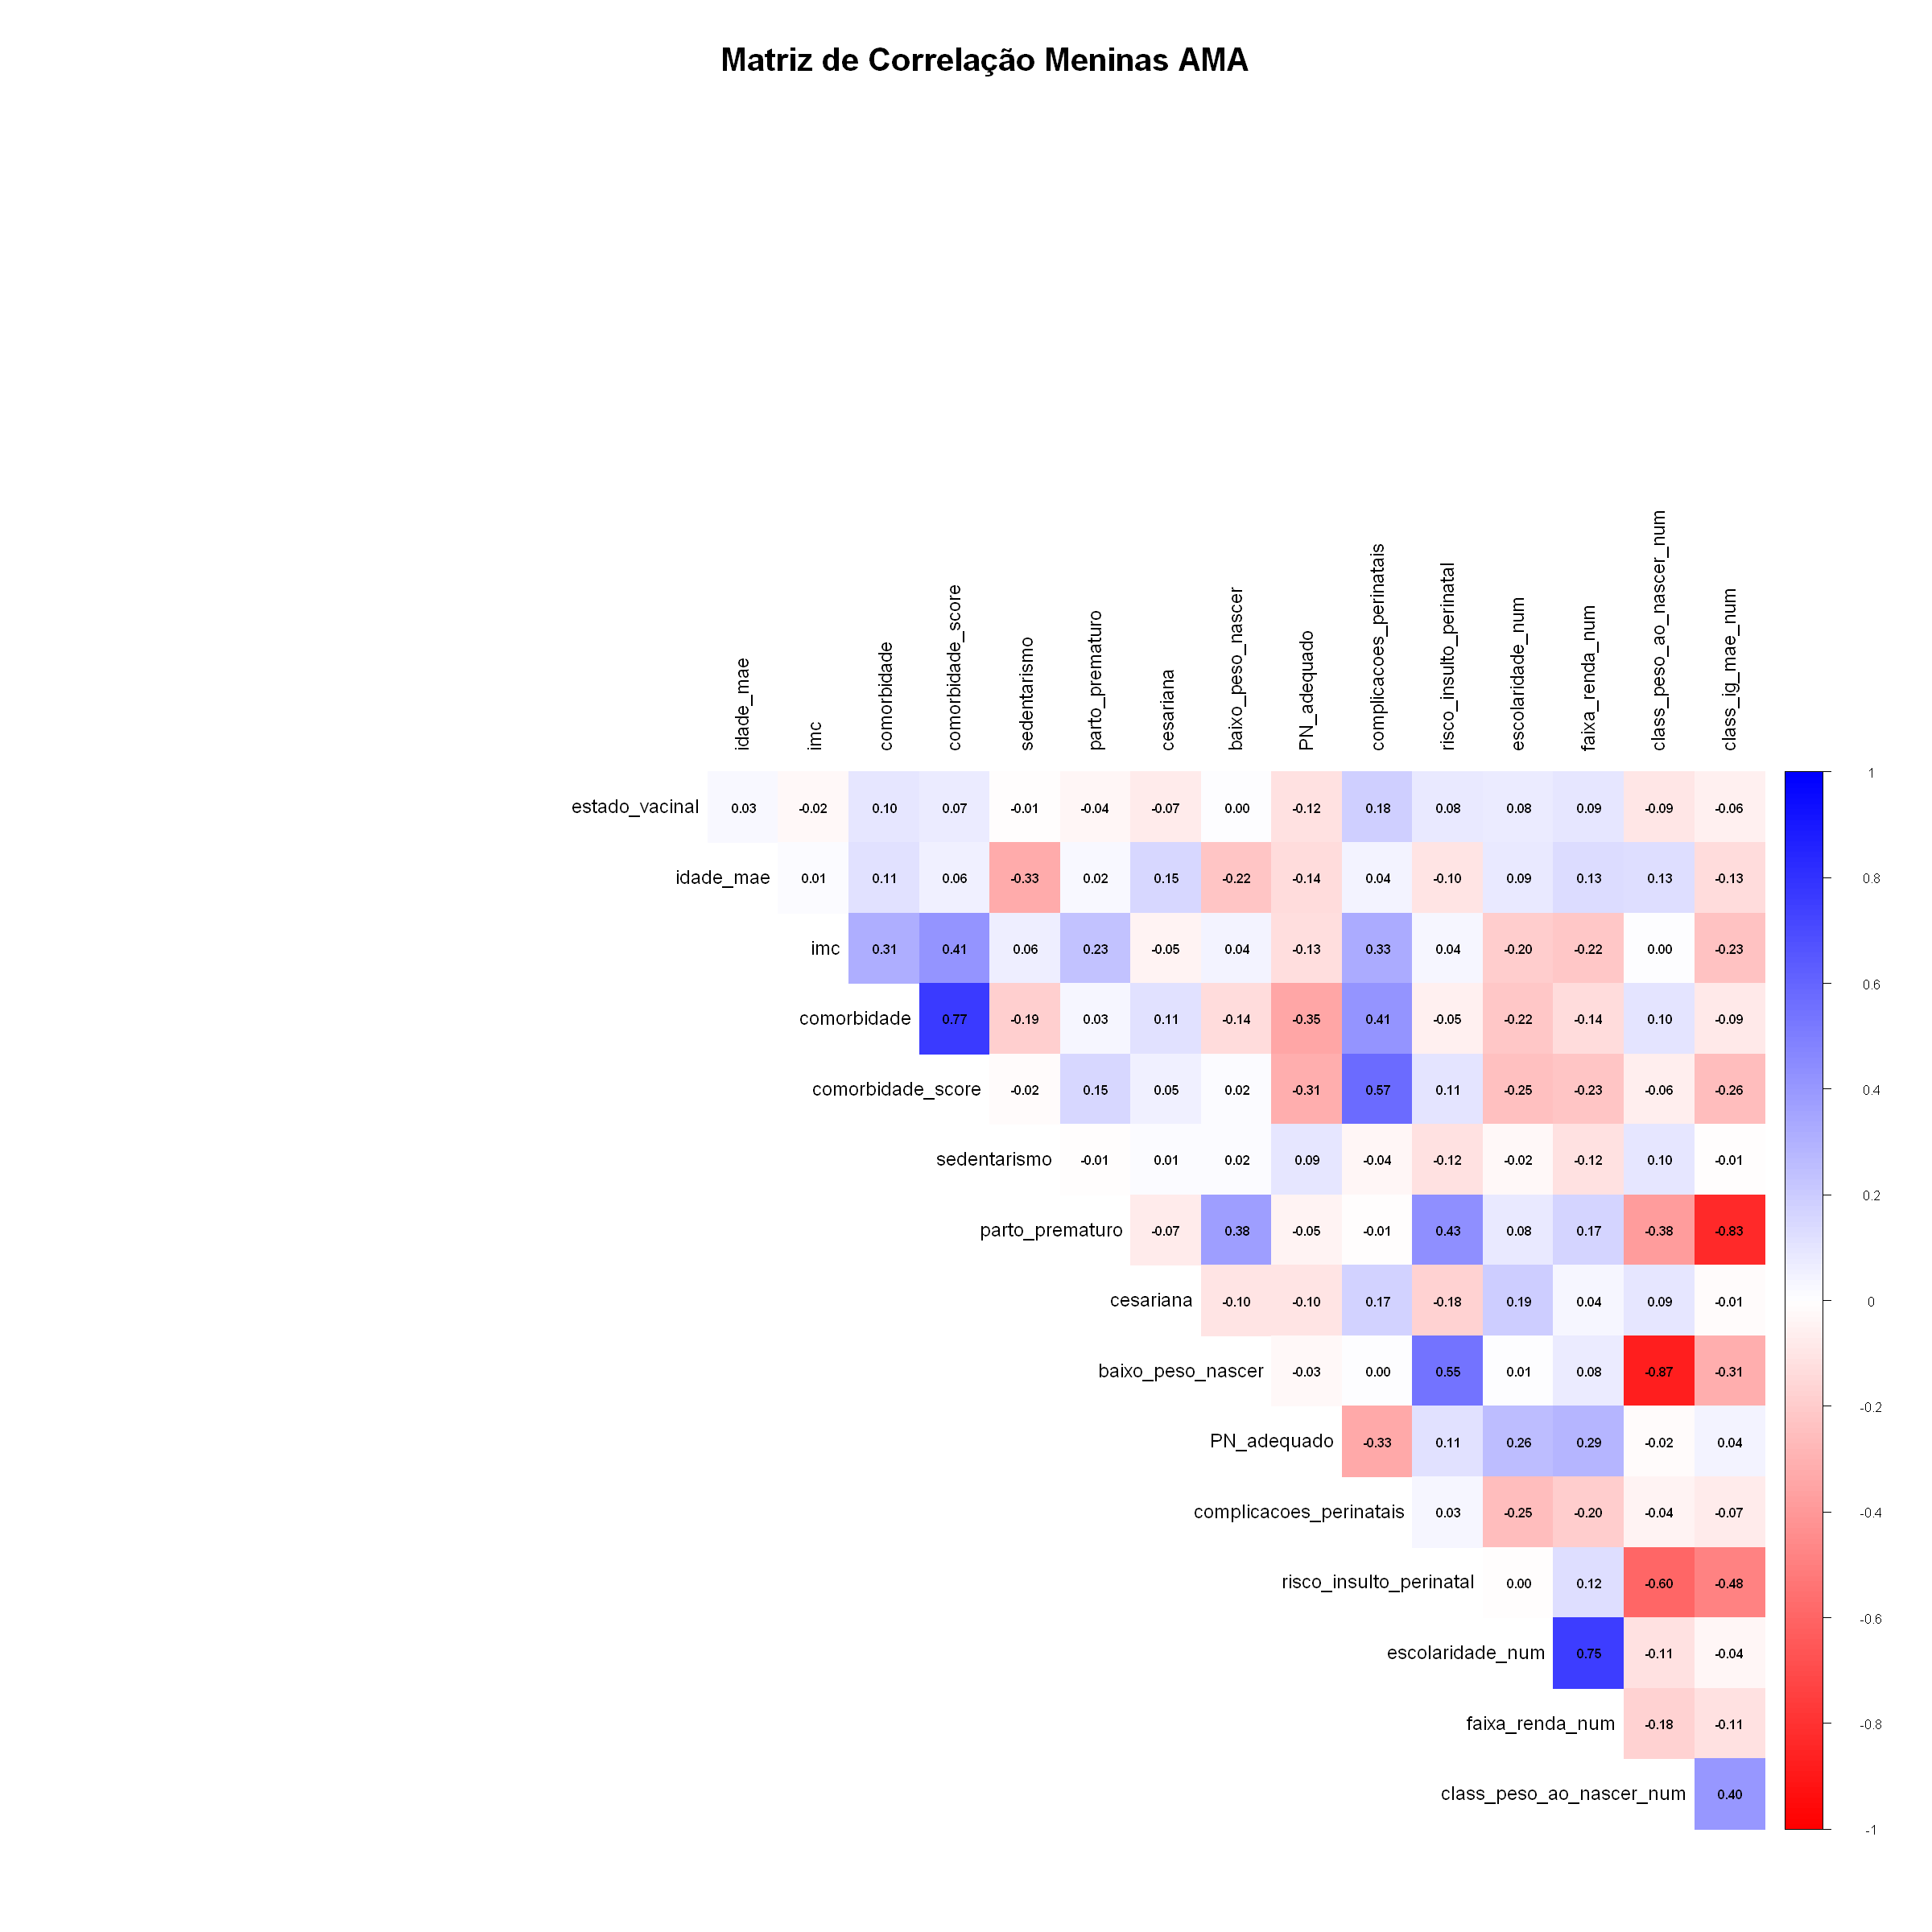

In [105]:
df_grupo_meninas_ama <- df_grupo %>% filter(sexo_num == 0, AMA == 1)
plot_survey_corr(df_grupo_meninas_ama, "Matriz de Correlação Meninas AMA")

### AMA =0 Meninos

Número de linhas no dataframe: 3192

Gráfico salvo como: Matriz de Correlação Meninos Não AMA.png



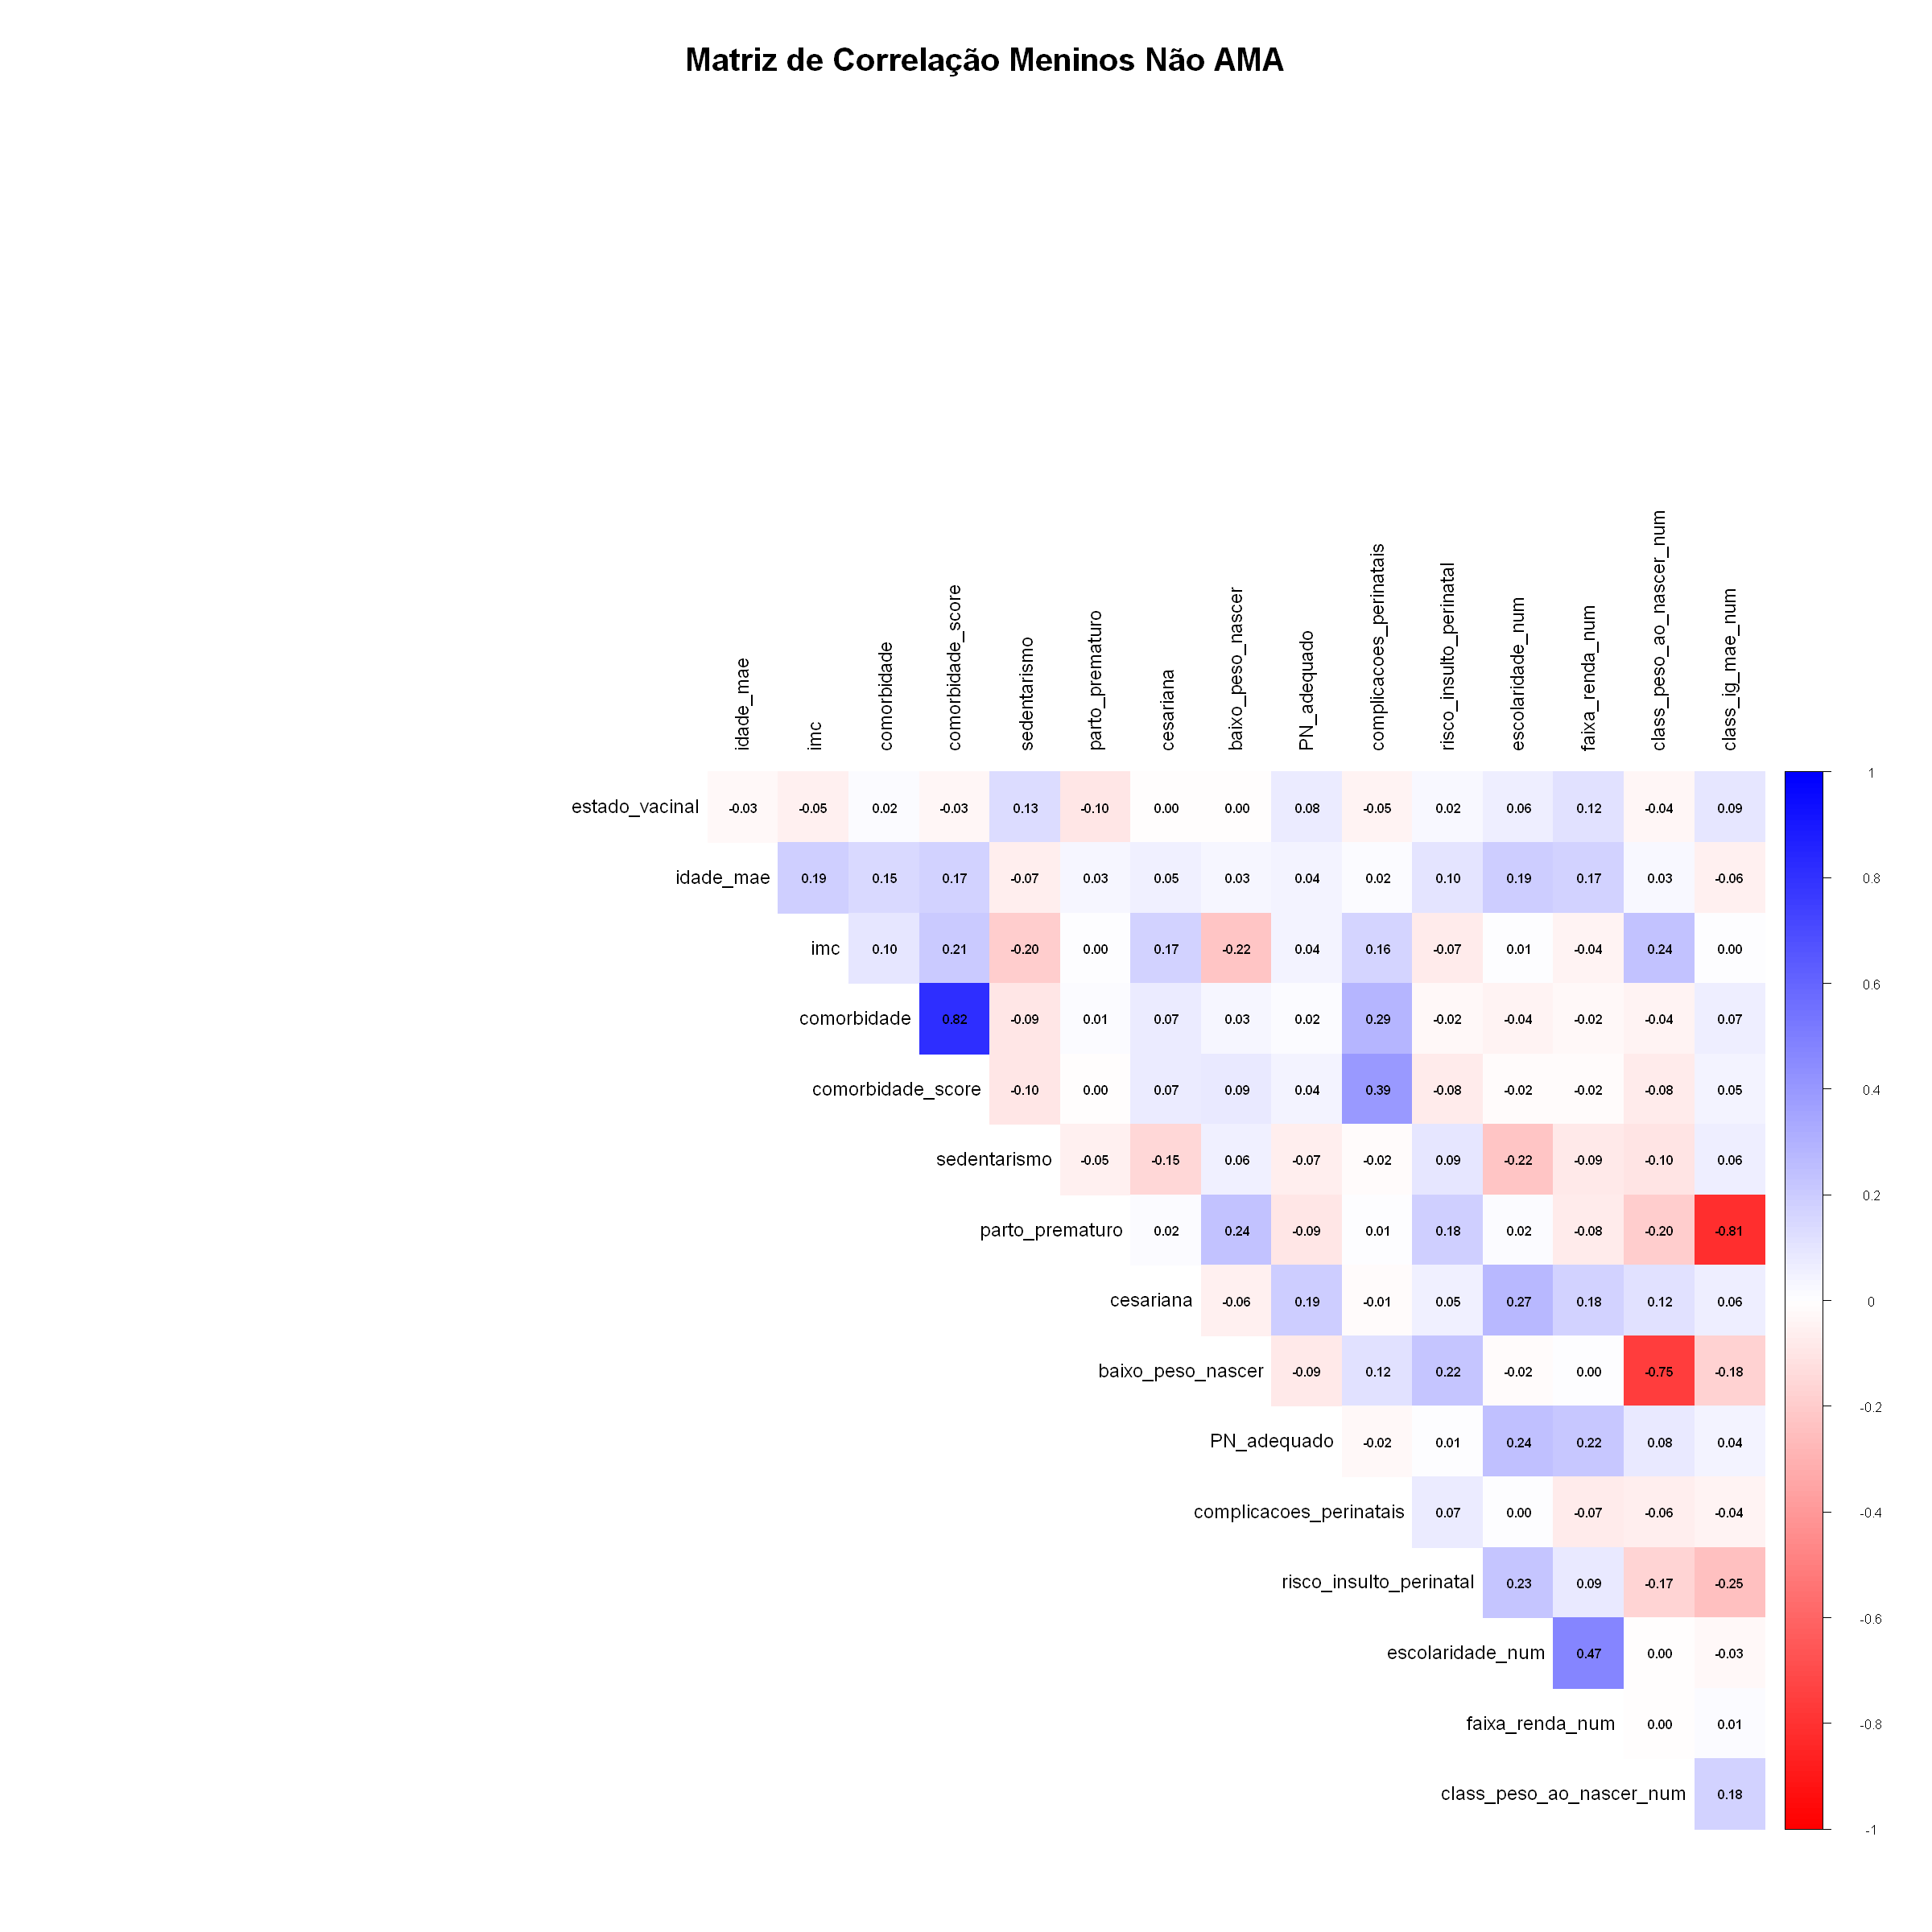

In [106]:
df_grupo_meninos_Nama <- df_grupo %>% filter(sexo_num == 1, AMA == 0)
plot_survey_corr(df_grupo_meninos_Nama, "Matriz de Correlação Meninos Não AMA")

### AMA=0 Meninas

Número de linhas no dataframe: 3098



Gráfico salvo como: Matriz de Correlação Meninas Não AMA.png



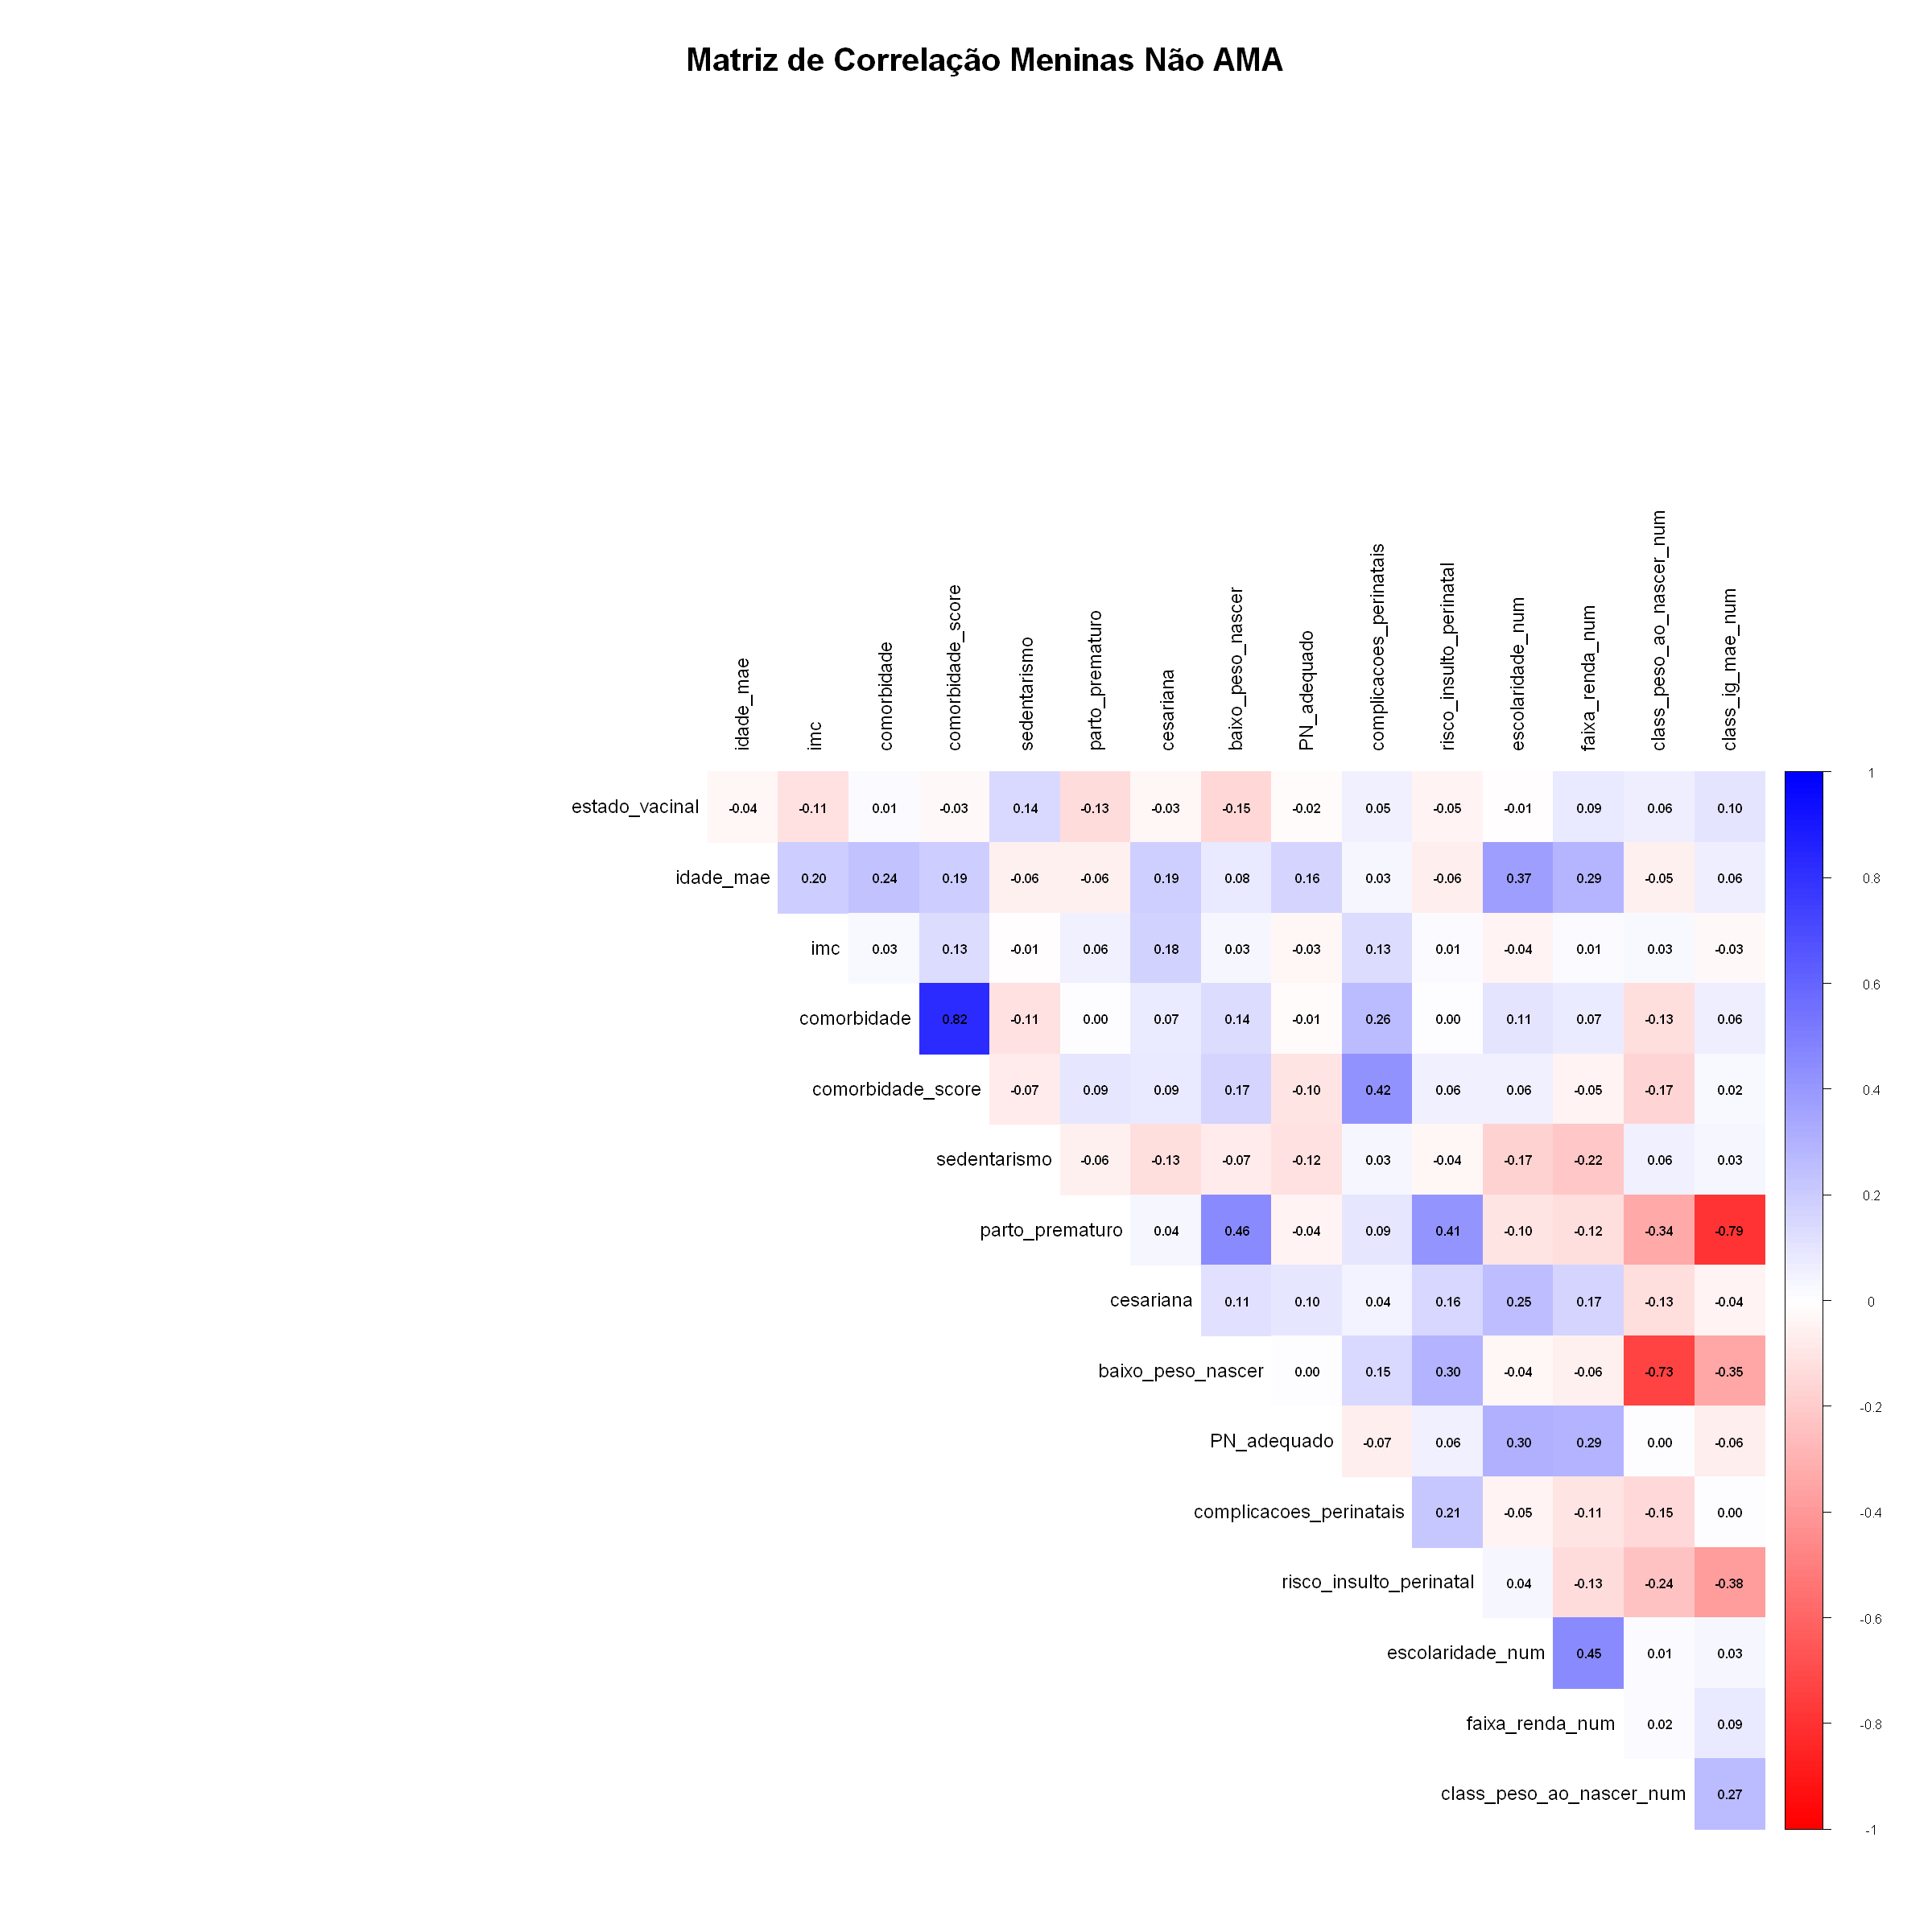

In [107]:
df_grupo_meninas_Nama <- df_grupo %>% filter(sexo_num == 0, AMA == 0)
plot_survey_corr(df_grupo_meninas_Nama, "Matriz de Correlação Meninas Não AMA")

In [100]:
df_grupo_deficiencia

estrato_filho,UPA_PNS_filho,sexo,idade_filho,cor_raca_filho,curso_mais_elevado_filho,usa_apoio_visao,dificuldade_enxergar_com_apoio,dificuldade_enxergar,usa_aparelho_auditivo,⋯,class_ig_mae,class_peso_ao_nascer,complicacoes_perinatais,risco_insulto_perinatal,filho,sexo_num,escolaridade_num,faixa_renda_num,class_peso_ao_nascer_num,class_ig_mae_num
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5310211,530015203,Homem,0,4,NA,NA,NA,NA,NA,⋯,Term,NBW,0,0,1,1,3,3,4,5
5310211,530026442,Homem,0,2,NA,NA,NA,NA,NA,⋯,Term,NBW,1,0,1,1,3,1,4,5
1450020,140007626,Homem,0,4,NA,NA,NA,NA,NA,⋯,Term,NBW,1,1,1,1,1,1,4,5
1450020,140007241,Homem,0,4,NA,NA,NA,NA,NA,⋯,Term,NBW,0,0,1,1,1,1,4,5
1450020,140006673,Homem,0,4,NA,NA,NA,NA,NA,⋯,Term,NBW,1,0,1,1,2,1,4,5
1450020,140002449,Homem,0,5,NA,NA,NA,NA,NA,⋯,NA,LBW,0,0,1,1,1,1,3,NA
5253011,520110978,Homem,0,5,NA,NA,NA,NA,NA,⋯,Term,NBW,0,0,1,1,3,2,4,5
5253012,520002100,Homem,0,4,NA,NA,NA,NA,NA,⋯,Term,NBW,1,0,1,1,1,1,4,5
5252022,520047750,Homem,0,4,NA,NA,NA,NA,NA,⋯,Term,NBW,0,0,1,1,2,1,4,5
